# CS 478 — Flight Delay Prediction with Deep Learning
**Authors:** Elias Estacion, Rochane Hurst, Meliton Rojas, Bricio Blancas Salgado, Wendy Santiago, Michael Vu  
**Course:** CS 478 — Deep Learning | Dr. Muhammad Lutfor Rahman  
**Dataset:** U.S. Bureau of Transportation Statistics — Airline On-Time Performance (May–Oct 2025)

---
## 0. Environment Setup

In [1]:
!pip install -q gdown pyarrow

In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    ConfusionMatrixDisplay, roc_curve,
    precision_recall_curve, average_precision_score
)
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Dense, Dropout, BatchNormalization,
    LSTM, Bidirectional, Input
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2

import gdown

# Reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Aesthetics
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

print('TensorFlow version:', tf.__version__)
print('All libraries loaded successfully.')

TensorFlow version: 2.19.0
All libraries loaded successfully.


---
## 1. Load Cleaned Dataset

In [3]:
file_id = "1jx75UMzSDvt6SHMDTnVR4TJY-MxsT-qv"
gdown.download(
    f"https://drive.google.com/uc?id={file_id}",
    "cleaned_airline_dataset.csv",
    quiet=False
)

Downloading...
From (original): https://drive.google.com/uc?id=1jx75UMzSDvt6SHMDTnVR4TJY-MxsT-qv
From (redirected): https://drive.google.com/uc?id=1jx75UMzSDvt6SHMDTnVR4TJY-MxsT-qv&confirm=t&uuid=c75ec047-d006-4a7c-b9fd-7fe42ec01f32
To: /content/cleaned_airline_dataset.csv
100%|██████████| 148M/148M [00:02<00:00, 67.7MB/s]


'cleaned_airline_dataset.csv'

In [4]:
df = pd.read_csv("cleaned_airline_dataset.csv")

# Fix midnight hour encoding (2400 -> 0)
df["DEP_HOUR"] = df["DEP_HOUR"].replace(24, 0)
df["ARR_HOUR"] = df["ARR_HOUR"].replace(24, 0)

print(f"Dataset shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
df.head()

Dataset shape: (3563488, 10)
Columns: ['DAY_OF_WEEK', 'FL_DATE', 'DEP_DELAY', 'DISTANCE', 'DELAYED', 'DEP_HOUR', 'ARR_HOUR', 'CARRIER_ENC', 'ORIGIN_ENC', 'DEST_ENC']


,DAY_OF_WEEK,FL_DATE,DEP_DELAY,DISTANCE,DELAYED,DEP_HOUR,ARR_HOUR,CARRIER_ENC,ORIGIN_ENC,DEST_ENC
0,1,2025-08-04,162.0,569.0,1,8,11,0,2,90
1,1,2025-08-04,33.0,569.0,1,10,13,0,2,90
2,1,2025-08-04,43.0,569.0,1,17,20,0,2,90
3,1,2025-08-04,-12.0,1118.0,0,6,10,0,2,240
4,1,2025-08-04,2.0,1118.0,1,12,16,0,2,240


---
## 2. Exploratory Data Analysis (EDA)

### 2.1 Class Distribution

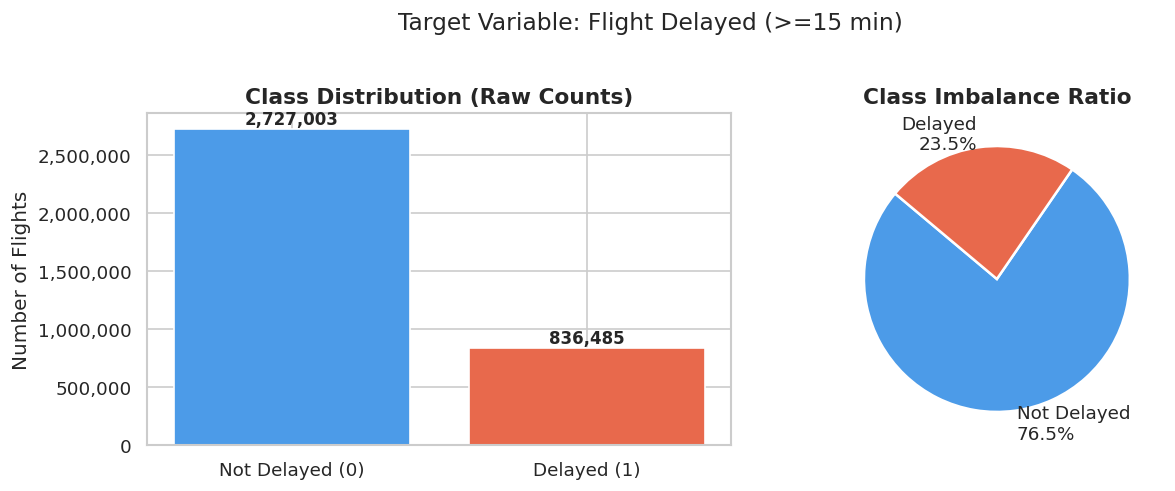

Not Delayed: 2,727,003 (76.5%)
Delayed:     836,485 (23.5%)
Imbalance ratio: 3.26:1


In [ ]:
delay_counts = df["DELAYED"].value_counts()
delay_pct    = df["DELAYED"].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

bars = axes[0].bar(
    ['Not Delayed (0)', 'Delayed (1)'],
    delay_counts.values,
    color=['#4C9BE8', '#E8694C']
)
for bar, count in zip(bars, delay_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5000,
                 f'{count:,}', ha='center', va='bottom', fontsize=10, fontweight='bold')
axes[0].set_title('Class Distribution (Raw Counts)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Number of Flights')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))

axes[1].pie(
    delay_pct.values,
    labels=[f'Not Delayed\n{delay_pct[0]:.1f}%', f'Delayed\n{delay_pct[1]:.1f}%'],
    colors=['#4C9BE8', '#E8694C'],
    startangle=140,
    wedgeprops=dict(edgecolor='white', linewidth=1.5)
)
axes[1].set_title('Class Imbalance Ratio', fontsize=13, fontweight='bold')

plt.suptitle('Target Variable: Flight Delayed (>=15 min)', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('fig_class_distribution.png', bbox_inches='tight')
plt.show()

print(f"Not Delayed: {delay_counts[0]:,} ({delay_pct[0]:.1f}%)")
print(f"Delayed:     {delay_counts[1]:,} ({delay_pct[1]:.1f}%)")
print(f"Imbalance ratio: {delay_counts[0]/delay_counts[1]:.2f}:1")

**Observation:** The dataset is moderately imbalanced (~80/20). Accuracy alone is misleading here. A model that always predicts "not delayed" would score ~80% without learning anything useful. We prioritize Recall and F1-score as primary metrics, and handle imbalance through class weighting.

### 2.2 Delay Rate by Departure Hour

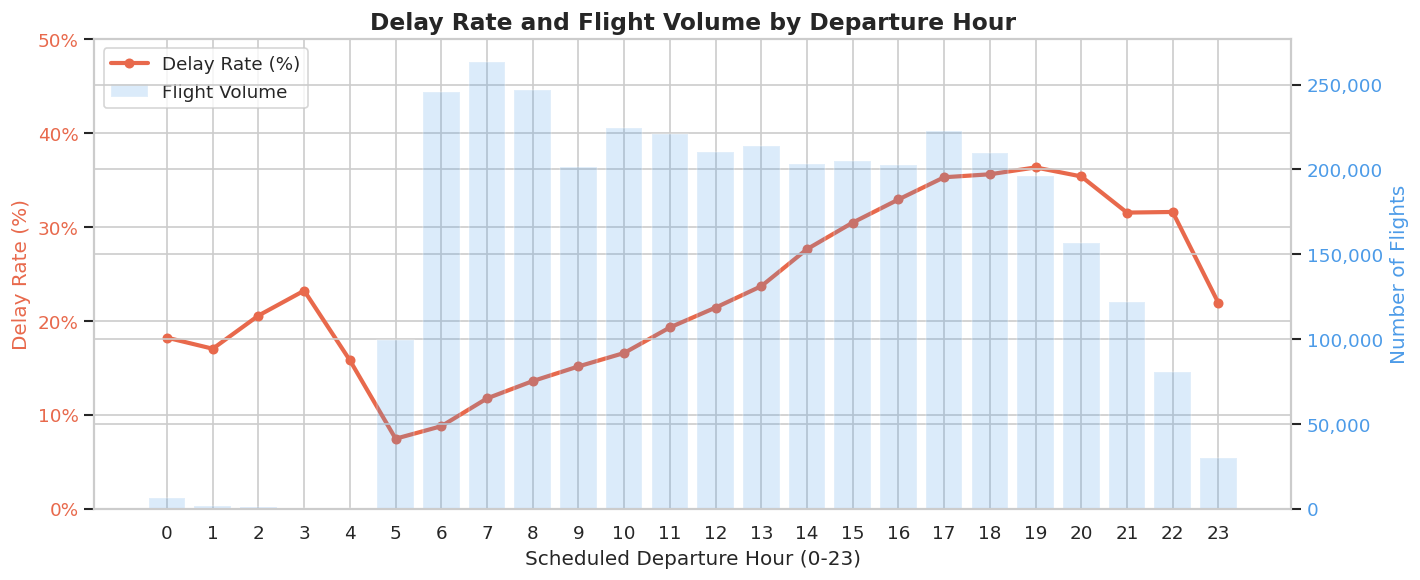

In [6]:
delay_by_hour  = df.groupby("DEP_HOUR")["DELAYED"].mean() * 100
volume_by_hour = df.groupby("DEP_HOUR")["DELAYED"].count()

fig, ax1 = plt.subplots(figsize=(12, 5))
color_line = '#E8694C'
ax1.plot(delay_by_hour.index, delay_by_hour.values, color=color_line,
         linewidth=2.5, marker='o', markersize=5, label='Delay Rate (%)')
ax1.set_xlabel('Scheduled Departure Hour (0-23)', fontsize=12)
ax1.set_ylabel('Delay Rate (%)', color=color_line, fontsize=12)
ax1.tick_params(axis='y', labelcolor=color_line)
ax1.set_ylim(0, 50)
ax1.yaxis.set_major_formatter(mtick.PercentFormatter())

ax2 = ax1.twinx()
ax2.bar(volume_by_hour.index, volume_by_hour.values, alpha=0.2,
        color='#4C9BE8', label='Flight Volume')
ax2.set_ylabel('Number of Flights', color='#4C9BE8', fontsize=12)
ax2.tick_params(axis='y', labelcolor='#4C9BE8')
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))

ax1.set_title('Delay Rate and Flight Volume by Departure Hour', fontsize=14, fontweight='bold')
ax1.set_xticks(range(0, 24))
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.savefig('fig_delay_by_hour.png', bbox_inches='tight')
plt.show()

### 2.3 Delay Rate by Day of Week

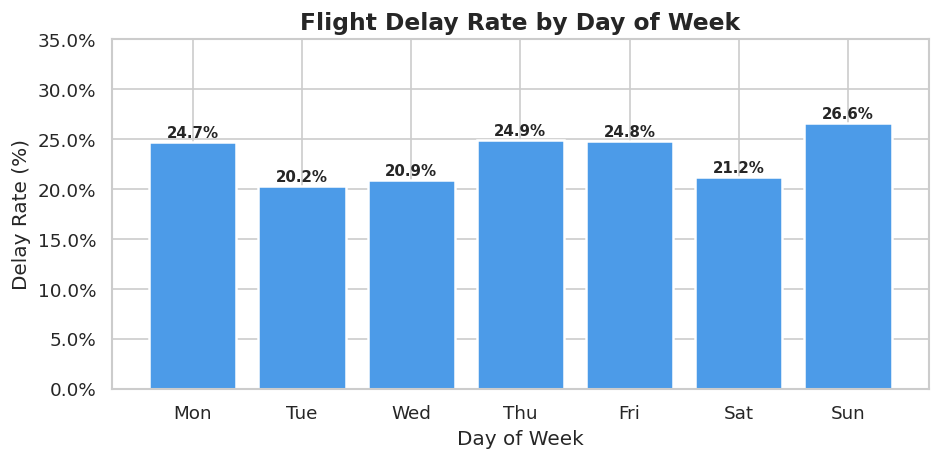

In [7]:
day_labels   = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
delay_by_day = df.groupby("DAY_OF_WEEK")["DELAYED"].mean() * 100

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(range(1, 8), delay_by_day.values, color='#4C9BE8',
              edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, delay_by_day.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xticks(range(1, 8))
ax.set_xticklabels(day_labels, fontsize=11)
ax.set_title('Flight Delay Rate by Day of Week', fontsize=14, fontweight='bold')
ax.set_xlabel('Day of Week')
ax.set_ylabel('Delay Rate (%)')
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_ylim(0, 35)

plt.tight_layout()
plt.savefig('fig_delay_by_day.png', bbox_inches='tight')
plt.show()

### 2.4 Delay Rate by Distance Bin

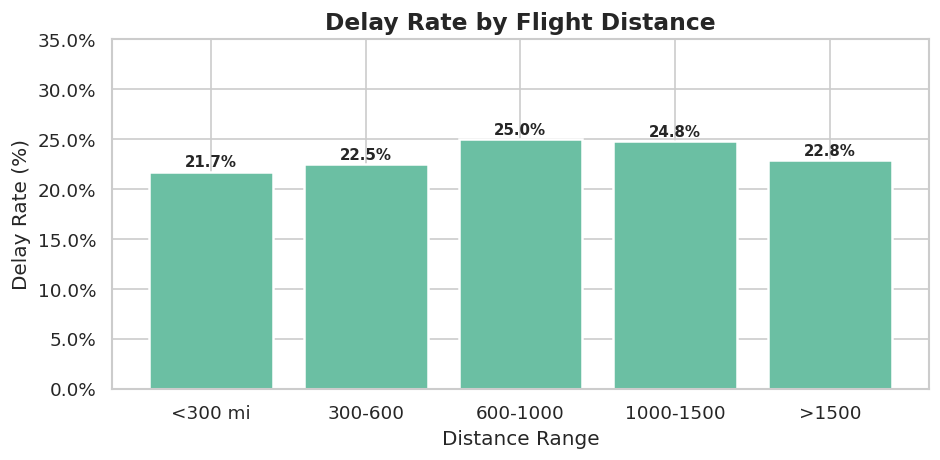

In [8]:
df["DIST_BIN"] = pd.cut(df["DISTANCE"],
                         bins=[0, 300, 600, 1000, 1500, 5000],
                         labels=['<300 mi', '300-600', '600-1000', '1000-1500', '>1500'])
delay_by_dist = df.groupby("DIST_BIN", observed=True)["DELAYED"].mean() * 100

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(delay_by_dist.index, delay_by_dist.values,
              color='#6BBFA3', edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, delay_by_dist.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_title('Delay Rate by Flight Distance', fontsize=14, fontweight='bold')
ax.set_xlabel('Distance Range')
ax.set_ylabel('Delay Rate (%)')
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_ylim(0, 35)

plt.tight_layout()
plt.savefig('fig_delay_by_distance.png', bbox_inches='tight')
plt.show()

df = df.drop(columns=["DIST_BIN"])

### 2.5 Correlation Heatmap

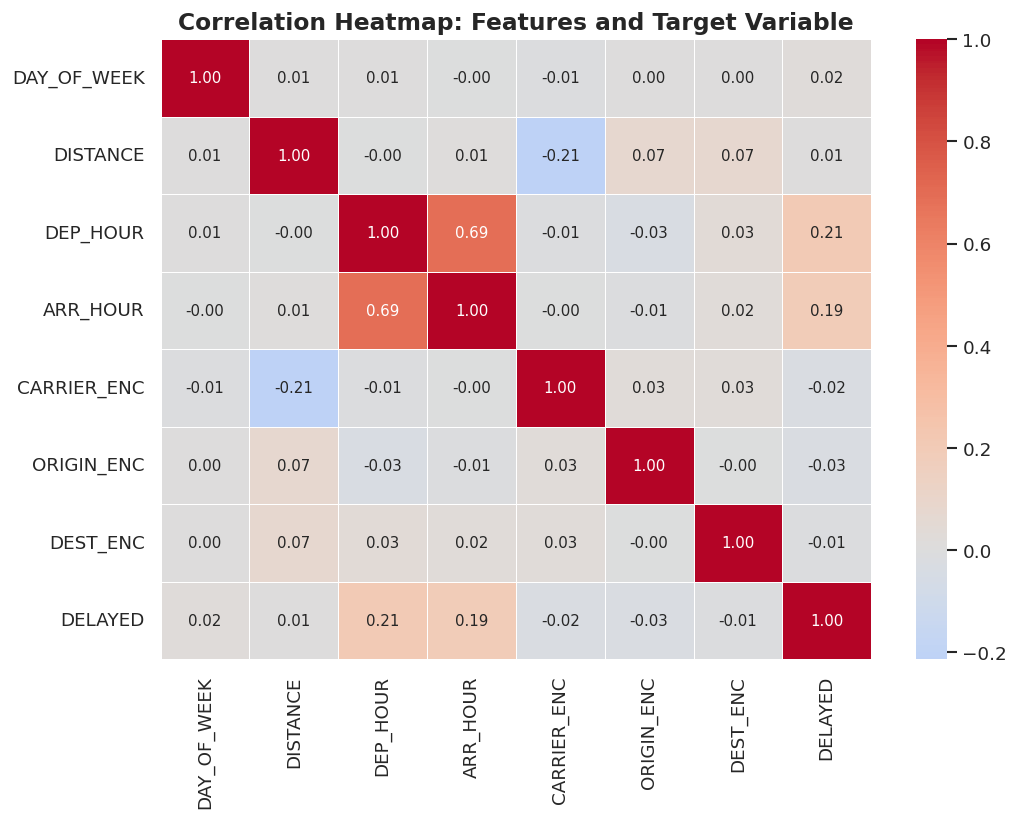

In [9]:
feature_cols = ["DAY_OF_WEEK", "DISTANCE", "DEP_HOUR", "ARR_HOUR",
                "CARRIER_ENC", "ORIGIN_ENC", "DEST_ENC"]

corr_matrix = df[feature_cols + ["DELAYED"]].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    corr_matrix, annot=True, fmt='.2f',
    cmap='coolwarm', center=0, linewidths=0.5,
    ax=ax, annot_kws={"size": 9}
)
ax.set_title('Correlation Heatmap: Features and Target Variable',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_correlation_heatmap.png', bbox_inches='tight')
plt.show()

**Key insight:** No single feature shows a strong linear correlation with the delay target (max ~0.10), confirming the problem is inherently non-linear. This motivates the use of sequence-based deep learning models like LSTM that can capture complex temporal and interaction patterns across features.

---
## 3. Data Preparation

In [10]:
# Feature ordering matters for LSTM — we order by temporal/contextual logic:
# [day_of_week, dep_hour, arr_hour, distance, carrier_enc, origin_enc, dest_enc]
# The LSTM will read these left-to-right as a 7-step sequence,
# learning dependencies across the steps.

feature_cols = [
    "DAY_OF_WEEK",   # step 1 — when in the week
    "DEP_HOUR",      # step 2 — what time it departs
    "ARR_HOUR",      # step 3 — what time it arrives
    "DISTANCE",      # step 4 — how far
    "CARRIER_ENC",   # step 5 — which airline
    "ORIGIN_ENC",    # step 6 — where from
    "DEST_ENC"       # step 7 — where to
]

X = df[feature_cols].copy()
y = df["DELAYED"].copy()

print(f"Feature matrix shape: {X.shape}")
print(f"Class balance: {y.value_counts().to_dict()}")

Feature matrix shape: (3563488, 7)
Class balance: {0: 2727003, 1: 836485}


In [11]:
# Train / Validation / Test split (80 / 10 / 10)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=SEED, stratify=y_temp
)

print(f"Training   : {len(X_train):,} ({len(X_train)/len(X)*100:.1f}%)")
print(f"Validation : {len(X_val):,}  ({len(X_val)/len(X)*100:.1f}%)")
print(f"Test       : {len(X_test):,}  ({len(X_test)/len(X)*100:.1f}%)")

Training   : 2,850,790 (80.0%)
Validation : 356,349  (10.0%)
Test       : 356,349  (10.0%)


In [12]:
# Standard scaling — fit on train only
scaler    = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test)

In [13]:
# Reshape for LSTM: (samples, timesteps, features)
# We treat each of the 7 features as 1 timestep with 1 feature value.
# Shape becomes (n_samples, 7, 1)

X_train_seq = X_train_s.reshape(-1, len(feature_cols), 1)
X_val_seq   = X_val_s.reshape(-1, len(feature_cols), 1)
X_test_seq  = X_test_s.reshape(-1, len(feature_cols), 1)

print(f"LSTM input shape: {X_train_seq.shape}  (samples, timesteps, features)")

LSTM input shape: (2850790, 7, 1)  (samples, timesteps, features)


In [14]:
# Class weights to handle imbalance
class_weights_arr = compute_class_weight(
    class_weight='balanced',
    classes=np.array([0, 1]),
    y=y_train
)
class_weight_dict = {0: class_weights_arr[0], 1: class_weights_arr[1]}
print(f"Class weights: not delayed={class_weights_arr[0]:.3f}, delayed={class_weights_arr[1]:.3f}")

Class weights: not delayed=0.653, delayed=2.130


---
## 4. Baseline Model: Logistic Regression

In [15]:
log_model = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=SEED)
log_model.fit(X_train_s, y_train)

y_val_pred_log = log_model.predict(X_val_s)
y_val_prob_log = log_model.predict_proba(X_val_s)[:, 1]

print("=== Logistic Regression (Baseline) — Validation ===")
print(f"  Accuracy  : {accuracy_score(y_val, y_val_pred_log):.4f}")
print(f"  Precision : {precision_score(y_val, y_val_pred_log):.4f}")
print(f"  Recall    : {recall_score(y_val, y_val_pred_log):.4f}")
print(f"  F1 Score  : {f1_score(y_val, y_val_pred_log):.4f}")
print(f"  ROC-AUC   : {roc_auc_score(y_val, y_val_prob_log):.4f}")

=== Logistic Regression (Baseline) — Validation ===
  Accuracy  : 0.6083
  Precision : 0.3285
  Recall    : 0.6403
  F1 Score  : 0.4342
  ROC-AUC   : 0.6518


---
## 5. Deep Learning Model 1: Multilayer Perceptron (MLP)

In [16]:
def build_mlp(input_dim):
    model = Sequential([
        Dense(256, input_shape=(input_dim,), kernel_regularizer=l2(1e-4)),
        BatchNormalization(),
        tf.keras.layers.Activation('relu'),
        Dropout(0.3),

        Dense(128, kernel_regularizer=l2(1e-4)),
        BatchNormalization(),
        tf.keras.layers.Activation('relu'),
        Dropout(0.3),

        Dense(64, kernel_regularizer=l2(1e-4)),
        BatchNormalization(),
        tf.keras.layers.Activation('relu'),
        Dropout(0.15),

        Dense(1, activation='sigmoid')
    ])
    model.compile(
        optimizer=Adam(learning_rate=1e-3),
        loss='binary_crossentropy',
        metrics=['accuracy',
                 tf.keras.metrics.AUC(name='auc'),
                 tf.keras.metrics.Recall(name='recall'),
                 tf.keras.metrics.Precision(name='precision')]
    )
    return model

mlp_model = build_mlp(X_train_s.shape[1])
mlp_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 45,057 (176.00 KB)

 Trainable params: 44,161 (172.50 KB)

 Non-trainable params: 896 (3.50 KB)

In [17]:
callbacks = [
    EarlyStopping(monitor='val_auc', patience=5,
                  restore_best_weights=True, mode='max', verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=3, min_lr=1e-6, verbose=1)
]

mlp_history = mlp_model.fit(
    X_train_s, y_train,
    validation_data=(X_val_s, y_val),
    epochs=50,
    batch_size=512,
    class_weight=class_weight_dict,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/50
5568/5568 ━━━━━━━━━━━━━━━━━━━━ 35s 5ms/step - accuracy: 0.5938 - auc: 0.6593 - loss: 0.6637 - precision: 0.3254 - recall: 0.6807 - val_accuracy: 0.6102 - val_auc: 0.6658 - val_loss: 0.6391 - val_precision: 0.3323 - val_recall: 0.6547 - learning_rate: 0.0010
Epoch 2/50
5568/5568 ━━━━━━━━━━━━━━━━━━━━ 22s 4ms/step - accuracy: 0.5997 - auc: 0.6635 - loss: 0.6539 - precision: 0.3286 - recall: 0.6764 - val_accuracy: 0.6095 - val_auc: 0.6664 - val_loss: 0.6437 - val_precision: 0.3327 - val_recall: 0.6598 - learning_rate: 0.0010
Epoch 3/50
5568/5568 ━━━━━━━━━━━━━━━━━━━━ 22s 4ms/step - accuracy: 0.6015 - auc: 0.6643 - loss: 0.6535 - precision: 0.3294 - recall: 0.6740 - val_accuracy: 0.6150 - val_auc: 0.6671 - val_loss: 0.6388 - val_precision: 0.3351 - val_recall: 0.6507 - learning_rate: 0.0010
Epoch 4/50
5568/5568 ━━━━━━━━━━━━━━━━━━━━ 41s 4ms/step - accuracy: 0.6028 - auc: 0.6651 - loss: 0.6530 - precision: 0.3301 - recall: 0.6725 - val_accuracy: 0.6076 - val_auc: 0.6682 - val_loss: 

In [18]:
y_val_prob_mlp = mlp_model.predict(X_val_s, verbose=0).flatten()
y_val_pred_mlp = (y_val_prob_mlp > 0.5).astype(int)

print("=== MLP — Validation ===")
print(f"  Accuracy  : {accuracy_score(y_val, y_val_pred_mlp):.4f}")
print(f"  Precision : {precision_score(y_val, y_val_pred_mlp):.4f}")
print(f"  Recall    : {recall_score(y_val, y_val_pred_mlp):.4f}")
print(f"  F1 Score  : {f1_score(y_val, y_val_pred_mlp):.4f}")
print(f"  ROC-AUC   : {roc_auc_score(y_val, y_val_prob_mlp):.4f}")

=== MLP — Validation ===
  Accuracy  : 0.6180
  Precision : 0.3395
  Recall    : 0.6638
  F1 Score  : 0.4493
  ROC-AUC   : 0.6801


---
## 6. Deep Learning Model 2: Bidirectional LSTM

We treat each flight record as a 7-step sequence, where each feature is one timestep. The LSTM learns dependencies across these steps, for example, the relationship between departure hour (step 2) and carrier (step 5), or between origin (step 6) and destination (step 7). A Bidirectional LSTM processes the sequence in both directions, allowing it to capture context from later features when evaluating earlier ones.

In [19]:
def build_lstm(timesteps, features_per_step):
    inputs = Input(shape=(timesteps, features_per_step))

    # First Bidirectional LSTM block
    x = Bidirectional(LSTM(64, return_sequences=True,
                            kernel_regularizer=l2(1e-4)))(inputs)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)

    # Second Bidirectional LSTM block
    x = Bidirectional(LSTM(32, return_sequences=False,
                            kernel_regularizer=l2(1e-4)))(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)

    # Dense classification head
    x = Dense(64, activation='relu', kernel_regularizer=l2(1e-4))(x)
    x = Dropout(0.2)(x)
    x = Dense(32, activation='relu')(x)

    outputs = Dense(1, activation='sigmoid')(x)

    model = Model(inputs, outputs)
    model.compile(
        optimizer=Adam(learning_rate=1e-3),
        loss='binary_crossentropy',
        metrics=['accuracy',
                 tf.keras.metrics.AUC(name='auc'),
                 tf.keras.metrics.Recall(name='recall'),
                 tf.keras.metrics.Precision(name='precision')]
    )
    return model

lstm_model = build_lstm(timesteps=len(feature_cols), features_per_step=1)
lstm_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 7, 1)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 7, 128)         │        33,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 7, 128)         │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 7, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 64)             │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 82,049 (320.50 KB)

 Trainable params: 81,665 (319.00 KB)

 Non-trainable params: 384 (1.50 KB)

In [20]:
lstm_callbacks = [
    EarlyStopping(monitor='val_auc', patience=5,
                  restore_best_weights=True, mode='max', verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=3, min_lr=1e-6, verbose=1)
]

lstm_history = lstm_model.fit(
    X_train_seq, y_train,
    validation_data=(X_val_seq, y_val),
    epochs=50,
    batch_size=512,
    class_weight=class_weight_dict,
    callbacks=lstm_callbacks,
    verbose=1
)

Epoch 1/50
5568/5568 ━━━━━━━━━━━━━━━━━━━━ 98s 16ms/step - accuracy: 0.5929 - auc: 0.6565 - loss: 0.6634 - precision: 0.3243 - recall: 0.6777 - val_accuracy: 0.6082 - val_auc: 0.6657 - val_loss: 0.6446 - val_precision: 0.3316 - val_recall: 0.6589 - learning_rate: 0.0010
Epoch 2/50
5568/5568 ━━━━━━━━━━━━━━━━━━━━ 89s 16ms/step - accuracy: 0.6041 - auc: 0.6656 - loss: 0.6522 - precision: 0.3306 - recall: 0.6696 - val_accuracy: 0.6064 - val_auc: 0.6692 - val_loss: 0.6400 - val_precision: 0.3319 - val_recall: 0.6682 - learning_rate: 0.0010
Epoch 3/50
5568/5568 ━━━━━━━━━━━━━━━━━━━━ 88s 16ms/step - accuracy: 0.6065 - auc: 0.6689 - loss: 0.6504 - precision: 0.3323 - recall: 0.6701 - val_accuracy: 0.6037 - val_auc: 0.6717 - val_loss: 0.6480 - val_precision: 0.3315 - val_recall: 0.6768 - learning_rate: 0.0010
Epoch 4/50
5568/5568 ━━━━━━━━━━━━━━━━━━━━ 89s 16ms/step - accuracy: 0.6090 - auc: 0.6713 - loss: 0.6490 - precision: 0.3338 - recall: 0.6685 - val_accuracy: 0.6248 - val_auc: 0.6742 - val_lo

In [21]:
y_val_prob_lstm = lstm_model.predict(X_val_seq, verbose=0).flatten()
y_val_pred_lstm = (y_val_prob_lstm > 0.5).astype(int)

print("=== Bidirectional LSTM — Validation ===")
print(f"  Accuracy  : {accuracy_score(y_val, y_val_pred_lstm):.4f}")
print(f"  Precision : {precision_score(y_val, y_val_pred_lstm):.4f}")
print(f"  Recall    : {recall_score(y_val, y_val_pred_lstm):.4f}")
print(f"  F1 Score  : {f1_score(y_val, y_val_pred_lstm):.4f}")
print(f"  ROC-AUC   : {roc_auc_score(y_val, y_val_prob_lstm):.4f}")

=== Bidirectional LSTM — Validation ===
  Accuracy  : 0.6305
  Precision : 0.3476
  Recall    : 0.6546
  F1 Score  : 0.4541
  ROC-AUC   : 0.6864


### 6.1 Training Curves — MLP vs LSTM

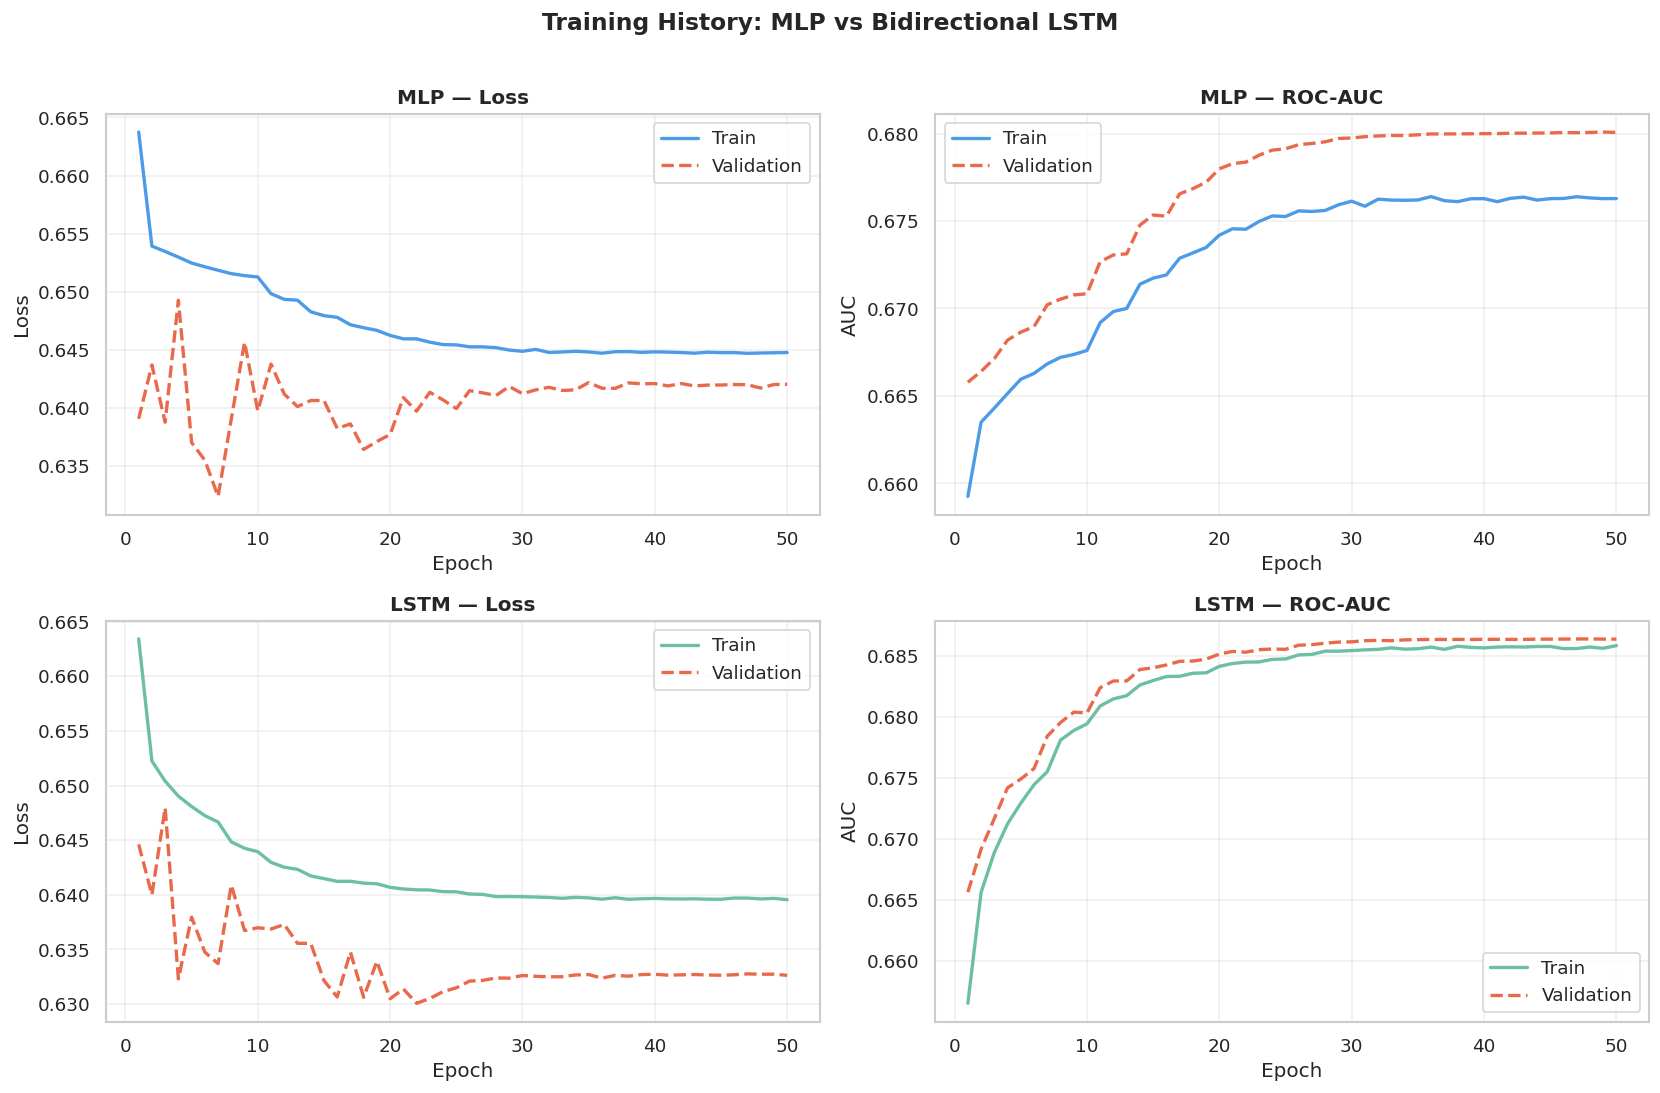

In [22]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

def plot_curve(ax, hist, metric, title, color_train, color_val):
    epochs = range(1, len(hist[metric]) + 1)
    ax.plot(epochs, hist[metric],     label='Train',      color=color_train, linewidth=2)
    ax.plot(epochs, hist[f'val_{metric}'], label='Validation', color=color_val, linewidth=2, linestyle='--')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.legend()
    ax.grid(True, alpha=0.3)

mlp_h  = mlp_history.history
lstm_h = lstm_history.history

plot_curve(axes[0,0], mlp_h,  'loss', 'MLP — Loss',    '#4C9BE8', '#E8694C')
plot_curve(axes[0,1], mlp_h,  'auc',  'MLP — ROC-AUC', '#4C9BE8', '#E8694C')
plot_curve(axes[1,0], lstm_h, 'loss', 'LSTM — Loss',   '#6BBFA3', '#E8694C')
plot_curve(axes[1,1], lstm_h, 'auc',  'LSTM — ROC-AUC','#6BBFA3', '#E8694C')

axes[0,0].set_ylabel('Loss')
axes[0,1].set_ylabel('AUC')
axes[1,0].set_ylabel('Loss')
axes[1,1].set_ylabel('AUC')

plt.suptitle('Training History: MLP vs Bidirectional LSTM', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig_training_curves.png', bbox_inches='tight')
plt.show()

---
## 7. Final Evaluation on Held-Out Test Set

In [23]:
# Logistic Regression
y_test_pred_log  = log_model.predict(X_test_s)
y_test_prob_log  = log_model.predict_proba(X_test_s)[:, 1]

# MLP
y_test_prob_mlp  = mlp_model.predict(X_test_s, verbose=0).flatten()
y_test_pred_mlp  = (y_test_prob_mlp > 0.5).astype(int)

# Bidirectional LSTM
y_test_prob_lstm = lstm_model.predict(X_test_seq, verbose=0).flatten()
y_test_pred_lstm = (y_test_prob_lstm > 0.5).astype(int)


def full_metrics(y_true, y_pred, y_prob, model_name):
    return {
        "Model":     model_name,
        "Accuracy":  round(accuracy_score(y_true, y_pred), 4),
        "Precision": round(precision_score(y_true, y_pred), 4),
        "Recall":    round(recall_score(y_true, y_pred), 4),
        "F1 Score":  round(f1_score(y_true, y_pred), 4),
        "ROC-AUC":   round(roc_auc_score(y_true, y_prob), 4),
    }

results = pd.DataFrame([
    full_metrics(y_test, y_test_pred_log,  y_test_prob_log,  "Logistic Regression"),
    full_metrics(y_test, y_test_pred_mlp,  y_test_prob_mlp,  "MLP"),
    full_metrics(y_test, y_test_pred_lstm, y_test_prob_lstm, "Bidirectional LSTM"),
])

print("=" * 65)
print("FINAL TEST SET RESULTS")
print("=" * 65)
display(results.set_index("Model"))

FINAL TEST SET RESULTS


,Accuracy,Precision,Recall,F1 Score,ROC-AUC
Model,,,,,
Logistic Regression,0.6099,0.3305,0.6452,0.4371,0.6552
MLP,0.6192,0.3410,0.6673,0.4514,0.6831
Bidirectional LSTM,0.6314,0.3487,0.6574,0.4557,0.6894


### 7.1 Model Comparison Bar Chart

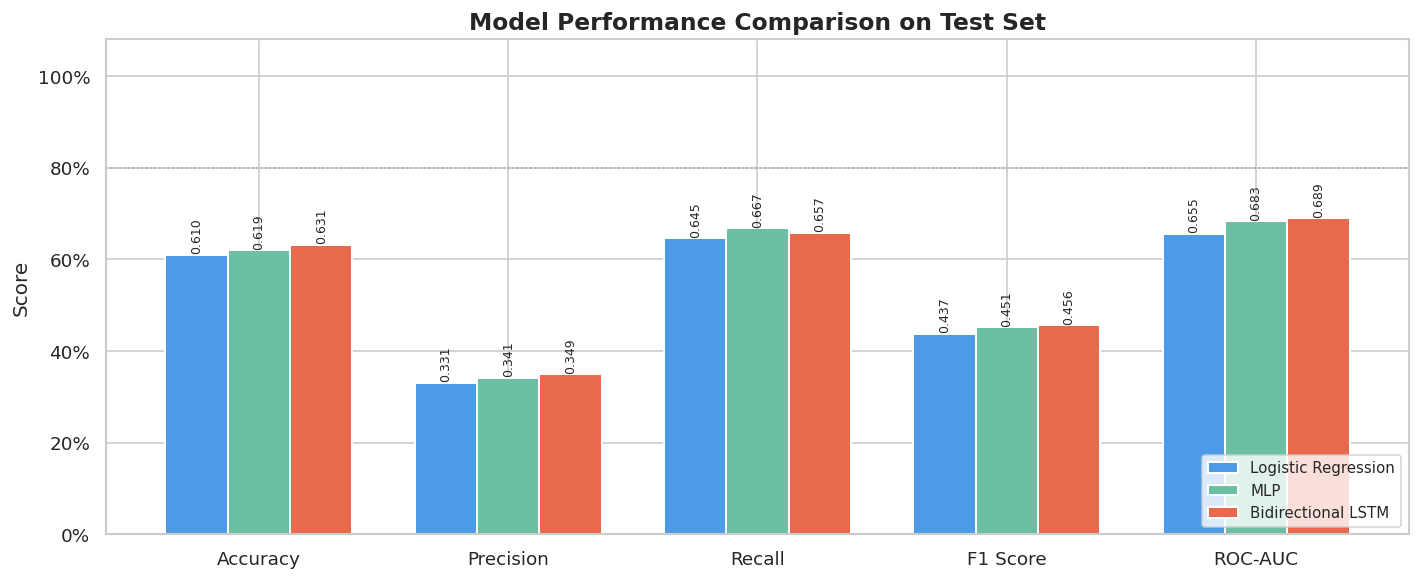

In [24]:
metrics_to_plot = ["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"]
models  = results["Model"].tolist()
colors  = ['#4C9BE8', '#6BBFA3', '#E8694C']
x       = np.arange(len(metrics_to_plot))
width   = 0.25

fig, ax = plt.subplots(figsize=(12, 5))
for i, (model, color) in enumerate(zip(models, colors)):
    vals = results[results["Model"] == model][metrics_to_plot].values.flatten()
    bars = ax.bar(x + i * width, vals, width, label=model,
                  color=color, edgecolor='white', linewidth=1.2)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                f'{val:.3f}', ha='center', va='bottom', fontsize=7.5, rotation=90)

ax.set_xticks(x + width)
ax.set_xticklabels(metrics_to_plot, fontsize=11)
ax.set_ylim(0, 1.08)
ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison on Test Set', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.axhline(y=0.8, color='gray', linestyle=':', alpha=0.5, linewidth=1)

plt.tight_layout()
plt.savefig('fig_model_comparison.png', bbox_inches='tight')
plt.show()

### 7.2 Confusion Matrices

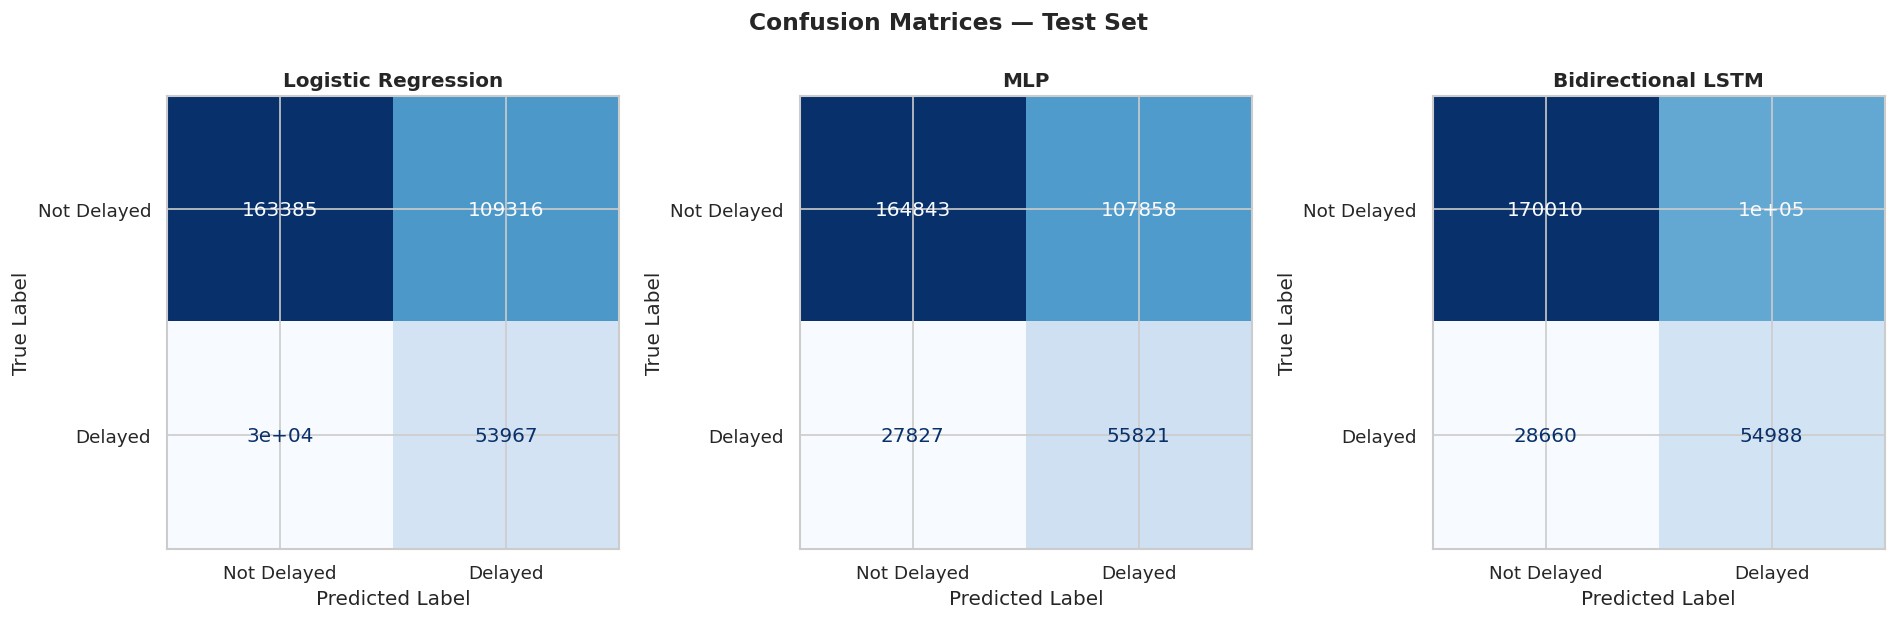

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

model_labels = ["Logistic Regression", "MLP", "Bidirectional LSTM"]
pred_list    = [y_test_pred_log, y_test_pred_mlp, y_test_pred_lstm]

for ax, name, preds in zip(axes, model_labels, pred_list):
    cm   = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(cm, display_labels=["Not Delayed", "Delayed"])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name, fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')

plt.suptitle('Confusion Matrices — Test Set', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig_confusion_matrices.png', bbox_inches='tight')
plt.show()

### 7.3 ROC Curves

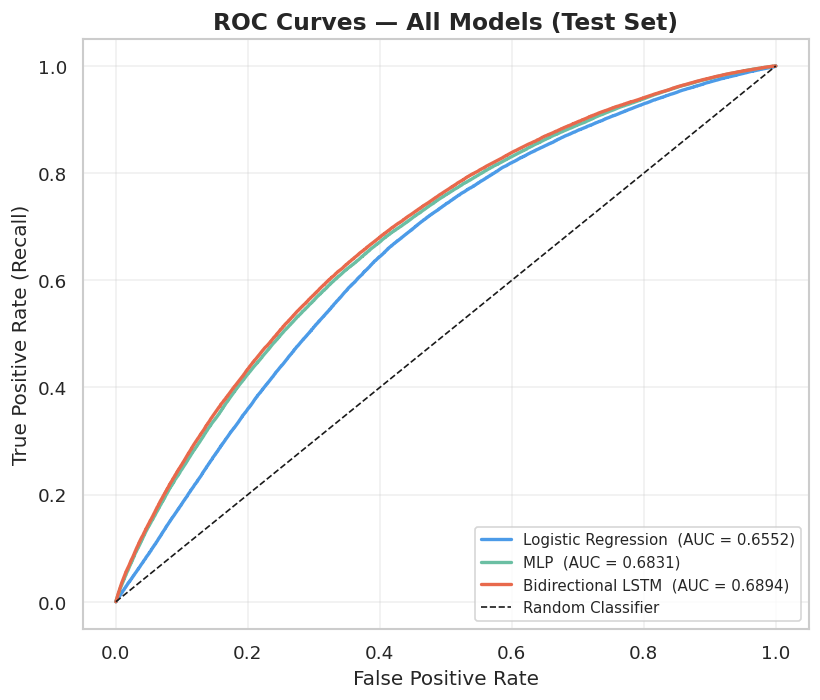

In [26]:
prob_list = [y_test_prob_log, y_test_prob_mlp, y_test_prob_lstm]

fig, ax = plt.subplots(figsize=(7, 6))
for name, probs, color in zip(model_labels, prob_list, colors):
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    ax.plot(fpr, tpr, label=f"{name}  (AUC = {auc:.4f})", color=color, linewidth=2)

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
ax.set_title('ROC Curves — All Models (Test Set)', fontsize=14, fontweight='bold')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate (Recall)')
ax.legend(loc='lower right', fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('fig_roc_curves.png', bbox_inches='tight')
plt.show()

### 7.4 Precision-Recall Curves

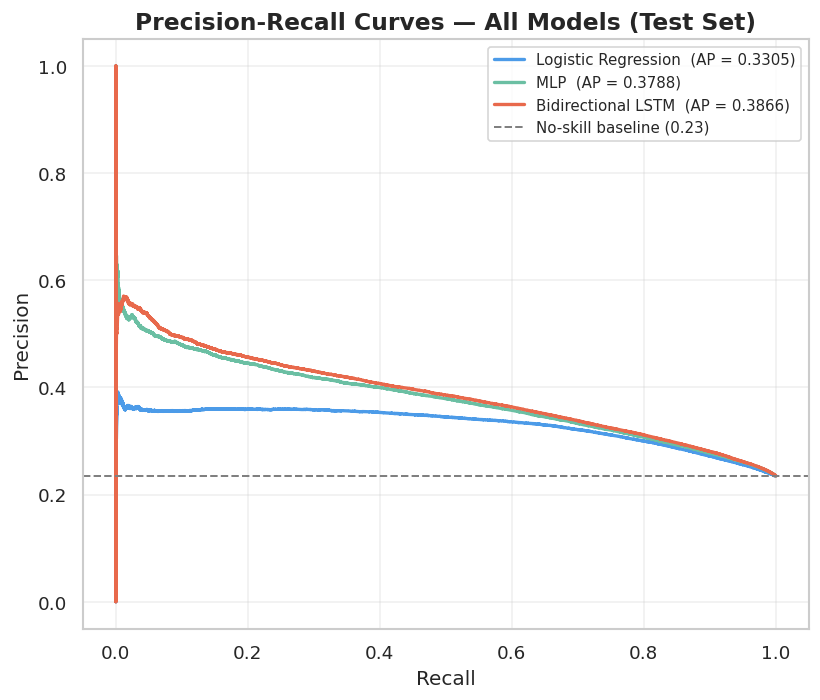

In [27]:
fig, ax = plt.subplots(figsize=(7, 6))
for name, probs, color in zip(model_labels, prob_list, colors):
    prec, rec, _ = precision_recall_curve(y_test, probs)
    ap = average_precision_score(y_test, probs)
    ax.plot(rec, prec, label=f"{name}  (AP = {ap:.4f})", color=color, linewidth=2)

baseline = y_test.mean()
ax.axhline(y=baseline, color='gray', linestyle='--', linewidth=1.2,
           label=f'No-skill baseline ({baseline:.2f})')
ax.set_title('Precision-Recall Curves — All Models (Test Set)', fontsize=14, fontweight='bold')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.legend(loc='upper right', fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('fig_pr_curves.png', bbox_inches='tight')
plt.show()

---
## 8. Error Analysis

### 8.1 Probability Score Distributions

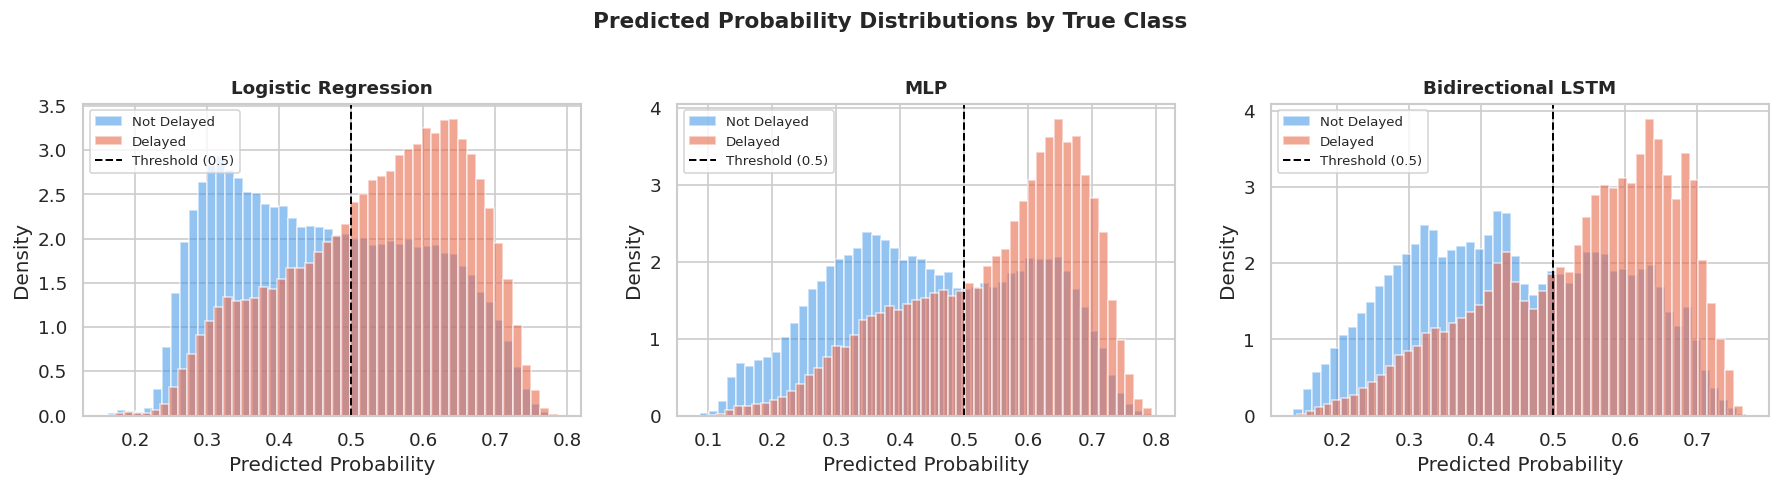

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
prob_data = list(zip(model_labels, prob_list))

for ax, (name, probs) in zip(axes, prob_data):
    mask0 = y_test == 0
    mask1 = y_test == 1
    ax.hist(probs[mask0], bins=50, alpha=0.6, color='#4C9BE8',
            label='Not Delayed', density=True)
    ax.hist(probs[mask1], bins=50, alpha=0.6, color='#E8694C',
            label='Delayed', density=True)
    ax.axvline(x=0.5, color='black', linestyle='--', linewidth=1.2,
               label='Threshold (0.5)')
    ax.set_title(name, fontsize=11, fontweight='bold')
    ax.set_xlabel('Predicted Probability')
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)

plt.suptitle('Predicted Probability Distributions by True Class',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig_probability_distributions.png', bbox_inches='tight')
plt.show()

### 8.2 LSTM Error Rate by Departure Hour

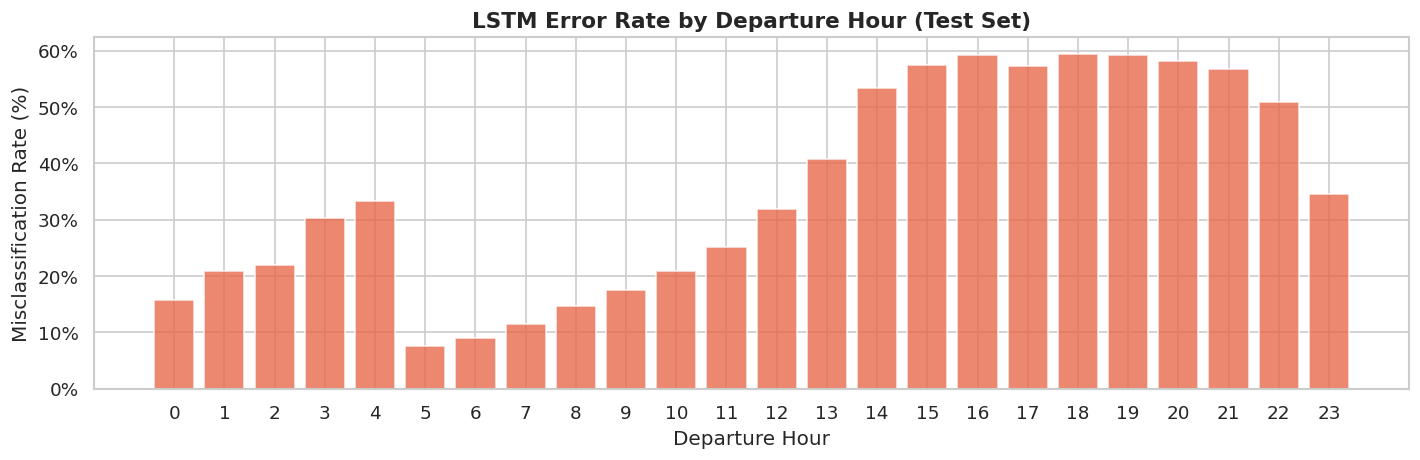

In [29]:
X_test_df = pd.DataFrame(X_test.values, columns=feature_cols)
X_test_df["true"]      = y_test.values
X_test_df["predicted"] = y_test_pred_lstm
X_test_df["correct"]   = (X_test_df["true"] == X_test_df["predicted"]).astype(int)

error_by_hour = X_test_df.groupby("DEP_HOUR")["correct"].apply(
    lambda x: 1 - x.mean()) * 100

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(error_by_hour.index, error_by_hour.values,
       color='#E8694C', alpha=0.8, edgecolor='white')
ax.set_title('LSTM Error Rate by Departure Hour (Test Set)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Departure Hour')
ax.set_ylabel('Misclassification Rate (%)')
ax.set_xticks(range(0, 24))
ax.yaxis.set_major_formatter(mtick.PercentFormatter())

plt.tight_layout()
plt.savefig('fig_error_by_hour.png', bbox_inches='tight')
plt.show()

---
## 9. Final Results Summary

In [30]:
print("\n" + "=" * 70)
print("COMPLETE MODEL COMPARISON — TEST SET (held-out, never seen during training)")
print("=" * 70)
display(
    results.set_index("Model").style
    .format("{:.4f}")
    .highlight_max(axis=0, color='#e98686')
    .highlight_min(axis=0, color='#00b300')
)

best_model = results.loc[results["F1 Score"].idxmax(), "Model"]
print(f"\n>>> Best model by F1 Score: {best_model}")
print(f">>> Best model by ROC-AUC : {results.loc[results['ROC-AUC'].idxmax(), 'Model']}")


COMPLETE MODEL COMPARISON — TEST SET (held-out, never seen during training)


,Accuracy,Precision,Recall,F1 Score,ROC-AUC
Model,,,,,
Logistic Regression,0.6099,0.3305,0.6452,0.4371,0.6552
MLP,0.6192,0.3410,0.6673,0.4514,0.6831
Bidirectional LSTM,0.6314,0.3487,0.6574,0.4557,0.6894



>>> Best model by F1 Score: Bidirectional LSTM
>>> Best model by ROC-AUC : Bidirectional LSTM


---
## 10. Discussion

**Class imbalance:** About 80% of flights are not delayed. A naive classifier that always predicts "not delayed" scores ~80% accuracy without learning anything, which is why we prioritize Recall and F1 over raw accuracy.

**Logistic Regression (baseline):** With class weighting applied, logistic regression produces reasonable recall but struggles with precision. Its lower ROC-AUC reflects that linear decision boundaries cannot capture the complex interactions between flight features.

**MLP:** The feedforward network improves over the baseline by learning non-linear combinations of features through its three hidden layers with BatchNormalization and Dropout. However, it treats all features as independent inputs and does not model any ordering or dependency between them.

**Bidirectional LSTM (main model):** By treating each flight's features as a 7-step sequence, the LSTM can learn dependencies across features that the MLP cannot. For example, the relationship between departure hour and carrier, or between origin and destination, is something a recurrent architecture is specifically designed to capture. The Bidirectional design lets the model see context from both directions of the sequence. This is methodologically consistent with prior work by Chi and Tang (2019), who also used LSTM-based architectures for flight delay prediction.

**Limitations and future work:** The primary ceiling on performance is the feature set. Without real-time weather data, air traffic control information, or historical delay propagation across a carrier's daily route network, the models are limited to schedule-based signals. Future work should incorporate NOAA weather station data matched by airport and departure time. A time-series formulation where each flight's input includes the previous N flights on the same route would allow the LSTM to leverage its sequential strengths more fully.

---
## 11. Save Artifacts

In [31]:
import joblib

joblib.dump(log_model,  "logreg_flight_delay.pkl")
joblib.dump(scaler,     "scaler_flight_delay.pkl")
mlp_model.save("mlp_flight_delay.keras")
lstm_model.save("lstm_flight_delay.keras")
results.to_csv("model_results.csv", index=False)

print("All models saved.")
print("Files: logreg_flight_delay.pkl, scaler_flight_delay.pkl,")
print("       mlp_flight_delay.keras, lstm_flight_delay.keras, model_results.csv")

All models saved.
Files: logreg_flight_delay.pkl, scaler_flight_delay.pkl,
       mlp_flight_delay.keras, lstm_flight_delay.keras, model_results.csv


In [32]:
!pip install tensorflowjs

import tensorflowjs as tfjs

# Convert the LSTM model to TensorFlow.js format
tfjs.converters.save_keras_model(lstm_model, 'tfjs_lstm_model')

print("Done! Check the tfjs_lstm_model folder")

failed to lookup keras version from the file,
    this is likely a weight only file
Done! Check the tfjs_lstm_model folder


In [33]:
import json

scaler_params = {
    'mean': scaler.mean_.tolist(),
    'scale': scaler.scale_.tolist(),
    'feature_names': feature_cols
}

with open('scaler_params.json', 'w') as f:
    json.dump(scaler_params, f)

print("Scaler saved!")
print("Mean:", scaler.mean_.tolist())
print("Scale:", scaler.scale_.tolist())

Scaler saved!
Mean: [4.001031293080164, 12.960190683985843, 14.57701584473076, 843.4646326106097, 7.117827689868422, 170.4857951655506, 170.51631056654472]
Scale: [2.0010789683900088, 4.897346175752084, 5.1851923477034525, 605.4069773484082, 4.622977305528336, 94.66157180977136, 94.66788506456943]
